In [1]:
# ── Cellule 1 : Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import json

print(f"SHAP version : {shap.__version__}")

SHAP version : 0.49.1


In [2]:
# ── Cellule 2 : Charger le modèle sauvegardé
# On n'a pas besoin de réentraîner — on recharge le modèle déjà sauvegardé
import joblib
with open('mon_modele_rh.pkl', 'rb') as f:
    data = joblib.load(f)

modele_final  = data['cerveau_ia']
preprocesseur = data['traitement']
seuil_optimal = data['reglage_seuil']
FEATURES      = data['features']
COLS_FINALES  = data['noms_colonnes']

print(f" Modèle chargé — Seuil : {seuil_optimal:.2f}")

 Modèle chargé — Seuil : 0.10


In [3]:
# 1. Charger les outils depuis ton kit
preprocesseur = data['traitement']
FEATURES      = data['features']

# 2. Charger les données brutes
df = pd.read_csv('hr.csv')

# 3. CRÉER LA VARIABLE MANQUANTE
# On transforme les données brutes (texte) en données processees (chiffres)
X_all_proc = preprocesseur.transform(df[FEATURES])

print(" X_all_proc est maintenant prêt pour les calculs SHAP !")

 X_all_proc est maintenant prêt pour les calculs SHAP !


In [4]:
import shap
import numpy as np
import pandas as pd

# 1. On récupère le booster
b = modele_final.get_booster()

# 2. MÉTHODE DE CONTOURNEMENT : On utilise "interventional"
# En passant 'data', on force SHAP à ignorer le base_score du modèle
# et à utiliser la moyenne des données pour l'explication.
try:
    print("Calcul SHAP en cours (méthode robuste)...")
    
    # On utilise un échantillon de 100 points pour la vitesse comme référence
    # cela évite de lire le paramètre [5E-1]
    explainer = shap.TreeExplainer(modele_final, 
                                   data=X_all_proc[:100], 
                                   feature_perturbation="interventional")
    
    # Calcul des valeurs SHAP
    shap_values = explainer.shap_values(X_all_proc)

    # 3. Ajustement du format pour SHAP 0.49 / XGBoost 3
    if isinstance(shap_values, list):
        # On prend la classe 1 (Départ)
        shap_values = shap_values[1]
    elif len(shap_values.shape) == 3:
        # Format (lignes, colonnes, classes) -> on prend la classe 1
        shap_values = shap_values[:, :, 1]
    
    print(f" SHAP calculé avec succès (Format : {shap_values.shape})")

except Exception as e:
    print(f" Échec de TreeExplainer : {e}")
    print("Tentative avec l'Explainer générique (plus lent mais infaillible)...")
    
    # Si TreeExplainer échoue encore, on utilise l'API moderne
    explainer = shap.Explainer(modele_final.predict, X_all_proc[:100])
    shap_result = explainer(X_all_proc)
    shap_values = shap_result.values
    print(" SHAP calculé avec l'Explainer générique !")
    

Calcul SHAP en cours (méthode robuste)...
 Échec de TreeExplainer : could not convert string to float: '[5E-1]'
Tentative avec l'Explainer générique (plus lent mais infaillible)...


PermutationExplainer explainer: 1471it [02:11, 10.50it/s]                          

 SHAP calculé avec l'Explainer générique !


In [5]:
# ── Cellule 5 : Importance globale
importance = np.abs(shap_values).mean(axis=0)
df_shap = pd.DataFrame({
    'Variable'   : COLS_FINALES,
    'Importance' : importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== TOP 10 VARIABLES ===")
for i, row in df_shap.head(10).iterrows():
    barre = "█" * int(row['Importance'] * 200)
    print(f"  {i+1:>2}. {row['Variable']:<40} {row['Importance']:.4f}  {barre}")

=== TOP 10 VARIABLES ===
   1. OverTime_Yes                             0.0659  █████████████
   2. MonthlyIncome                            0.0290  █████
   3. Age                                      0.0245  ████
   4. StockOptionLevel                         0.0240  ████
   5. YearsWithCurrManager                     0.0213  ████
   6. DistanceFromHome                         0.0183  ███
   7. NumCompaniesWorked                       0.0179  ███
   8. JobSatisfaction_Very High                0.0177  ███
   9. DailyRate                                0.0145  ██
  10. WorkLifeBalance_Better                   0.0141  ██


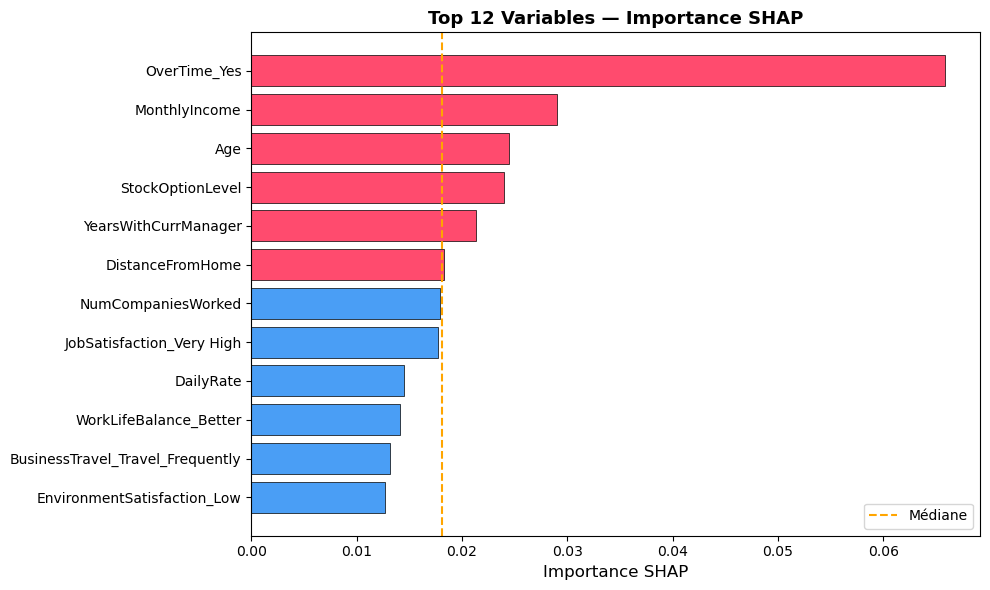

In [6]:
# ── Cellule 6 : Graphique importance globale
top12    = df_shap.head(12)
couleurs = ['#FF4B6E' if v > top12['Importance'].median() else '#4A9EF5'
            for v in top12['Importance']]

plt.figure(figsize=(10, 6))
plt.barh(top12['Variable'][::-1], top12['Importance'][::-1],
         color=couleurs[::-1], edgecolor='black', linewidth=0.5)
plt.axvline(x=top12['Importance'].median(), color='orange',
            linestyle='--', linewidth=1.5, label='Médiane')
plt.xlabel('Importance SHAP', fontsize=12)
plt.title('Top 12 Variables — Importance SHAP', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

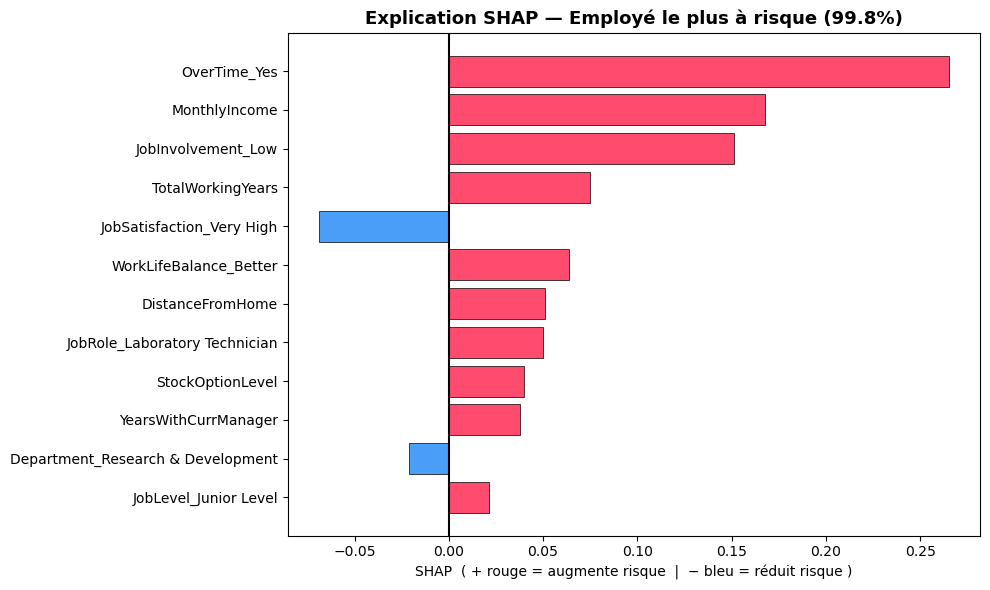

→ Facteur #1 : OverTime_Yes


In [7]:
# ── Cellule 7 : SHAP local (employé le plus à risque)
y_proba_all = modele_final.predict_proba(X_all_proc)[:, 1]
idx_max     = np.argmax(y_proba_all)
shap_emp    = shap_values[idx_max]
proba_emp   = y_proba_all[idx_max]

df_local = pd.DataFrame({
    'Variable': COLS_FINALES,
    'SHAP'    : shap_emp
}).sort_values('SHAP', key=abs, ascending=False).head(12)

couleurs_l = ['#FF4B6E' if v > 0 else '#4A9EF5' for v in df_local['SHAP']]

plt.figure(figsize=(10, 6))
plt.barh(df_local['Variable'][::-1], df_local['SHAP'][::-1],
         color=couleurs_l[::-1], edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=1.5)
plt.xlabel('SHAP  ( + rouge = augmente risque  |  − bleu = réduit risque )')
plt.title(f'Explication SHAP — Employé le plus à risque ({proba_emp*100:.1f}%)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"→ Facteur #1 : {df_local['Variable'].iloc[0]}")